# Motion annotation pipeline  

Annotate a motion signal into periods of high and low motion (indicative of arousal and rest respectively) and find finer motion events during rest.

Here the input signal is motion energy, but we can do same annotation with eye motion for example.

This notebook expects the following folder structure:

- dataset_id
      - camera_processed > 'motion_energy.npy'
      or

- dataset_id
      - behavioral_video > 'cam_crop.tiff' 


After annotation we can check several interesting things:

- How do movement types evolve across ages ? ( eg. in duration, amplitude, frequency)

- How much time in awake - rest we identify per age and how does it evolve ?

- If we track the eye (SLEAP) -> How much correlated the pupil signal is to the motion energy ? Can we identify eye specific motions ? (eg REM, or just twitches)

In [1]:
import os
# going to root directory (if not there yet)
current_dir = os.getcwd().split('/')[-1]
if current_dir != 'patchnmf':                   ##chnage
    os.chdir('..')
    os.chdir('..')

os.getcwd()

'C:\\Users\\zaggila\\Documents\\deve_2p'

In [2]:
# cd mousecraft

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile
from skimage import filters
from scipy.ndimage import label, binary_closing
from scipy.signal import savgol_filter
from scipy.stats import skew, kurtosis
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from diptest import diptest

from pathlib import Path
from PIL import Image
import imageio
import cv2

from patchnmf.data_io import *
from patchnmf.analyse.videography_compute import *
from patchnmf.analyse.videography_plot import *

In [4]:
# setting common plot params 
from matplotlib import rcParams

rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 15
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

In [5]:
def mkdir(path):
    if not os.path.exists(path): os.makedirs(path)
    return path

In [6]:
# set path 
data_path =  rf'\Users\zaggila\Documents\deve_2p\data_proc\cells_dual_img'

ds = 'test_mouse_id' 
fps = 15 # framerate of behavior recording 
target_fps = 3 # framerate after averaging for denoising (less averaging - higher detail - more events detected, but also more noise)

session_path = os.path.join(data_path, ds) # choose one specifc ds 

# if you have the behavioral video in .tif --> to compute motion energy
movie_path = os.path.join(session_path, 'cam_crop.tif') 

# Set parameters (in notebook or GUI)

This is important:
For binary step - Otsu is better if the distribution is indeed bimodal. Else try li (less strict, best for long-tale distributions) or mean+sd (strictest threshold-only big motions will be detected)

For twitch threshold, choose a threshold that will identify all other motions that occur during rest. The stricter the threshold the less events will be detected ('Li' is recommended for long-tailed distributions, but try a stricter threshold like Otsu or MAD to detect less but more evident motions)

In [7]:
# set parameters 
gaussian_sigma = 5

# Thresholds for binarisation and other event detection
binary_threshold_method = 'otsu'  # threshold for binary: a/r state detcetion -
twitch_threshold_method = 'li' # threshold for twitch detection (more permissive -> detect more/lose less)

# min duration of arousal-related motion
active_motion_duration_min =  fps * 1 # 1 sec 
# min duration of arousal-related motion to be considered long 
long_active_motion_duration_min = fps * 3 # at least 3 seconds to be considered a long awake motion eg run 
# maximum expected duration of twitch or saccade event 
twitch_duration_max = fps * 1 # change according to the event (if saccade lasts less than 1 sec for example, set to 1 sec)
# event minimum distance from another event 
twitch_min_distance_from_active = fps * 3  # at least 3 sec away from awake motion to be detected as twitch 
print(f' max_twitch_allowed: {twitch_duration_max/fps} sec') 

# whether to load eye tracked with SLEAP .csv file 
is_sleap = False

 max_twitch_allowed: 1.0 sec


In [8]:
# create saving folder 
save_dir = session_path
save_dir_videography = mkdir(f'{save_dir}/mousecraft_automatic_classifications')
save_dir_videography = Path(save_dir_videography)

# Compute/Load motion energy

In [9]:
motion_energy_orig = compute_motion_energy(session_path, movie_path=None, xrange=None, yrange=None, save_path=session_path) #if first run, provide movie_path

Motion energy already computed. Loading from \Users\zaggila\Documents\deve_2p\data_proc\cells_dual_img\test_mouse_id\camera_processed\motion_energy.npy


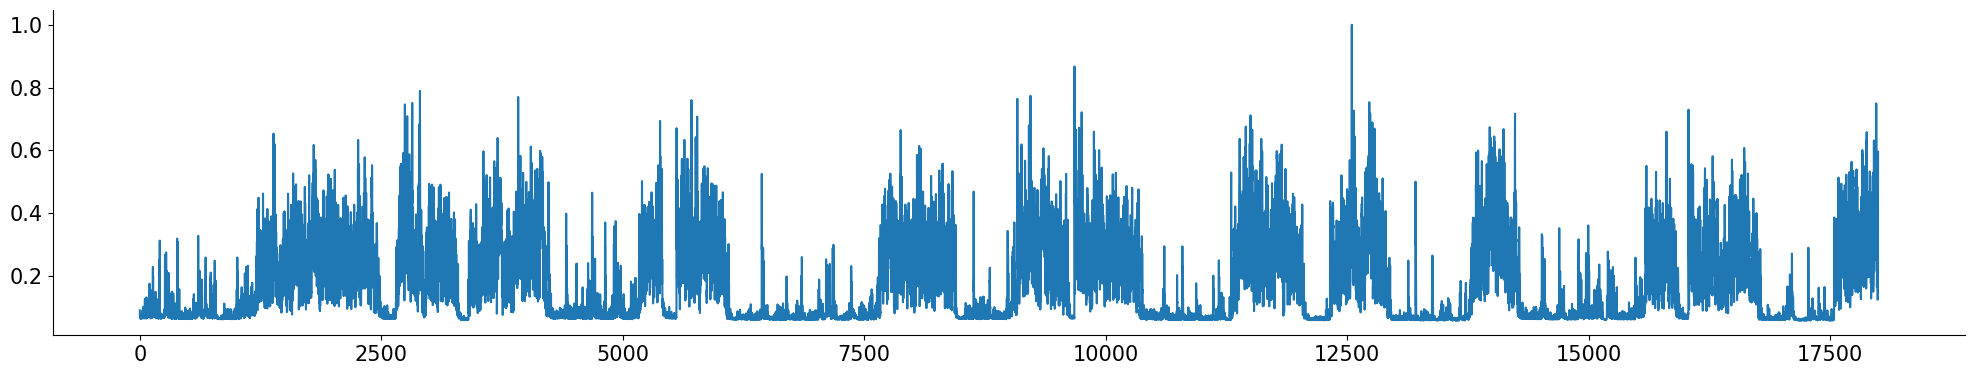

In [10]:
# plot motion 

plt.plot(motion_energy_orig)
plt.show()

# Load SLEAP output (if computed)

In [11]:
# load sleap output
if is_sleap is True:
    files = os.listdir(subject_path)
    csv_files = [f for f in files if f.endswith('.csv')]
    
    # Check if there is exactly one CSV file
    if len(csv_files) == 1:
        # Load the CSV file into a DataFrame
        sleap_output_path = os.path.join(subject_path, csv_files[0])  # Get full path to the CSV file
        sleap_output = pd.read_csv(sleap_output_path)  # Pass the file path
        print(f"Loaded {csv_files[0]}")
    else:
        if len(csv_files) == 0:
            raise FileNotFoundError("No CSV files found")
        else:
            raise FileExistsError("Multiple CSV files found. Please ensure there is only one CSV file in the subject directory.")

## Average motion signal before annotation 

In [12]:
avg_block = compute_downsample_factor(initial_fps=fps, target_fps=3)

In [13]:
if len(motion_energy_orig) % 2 != 0: 
    motion_energy = pad(motion_energy_orig)
    motion_energy = average_frames(motion_energy, avg_block = avg_block)
else:
    motion_energy = average_frames(motion_energy_orig, avg_block = avg_block)

 Congrats! New shape is 18000
Congrats again! Data is now 3600


In [14]:
length_acts = len(motion_energy)
# for plotting xticks to seconds
frame_ticks = range(0, length_acts+ 100, 300)  # 300 frames is 100 sec
second_ticks = [int(tick/fps) for tick in frame_ticks]   # Convert to seconds

### Compute SNR (signal to noise ratio) of motion signal & adjust smoothing 

Adaptive window length: 39


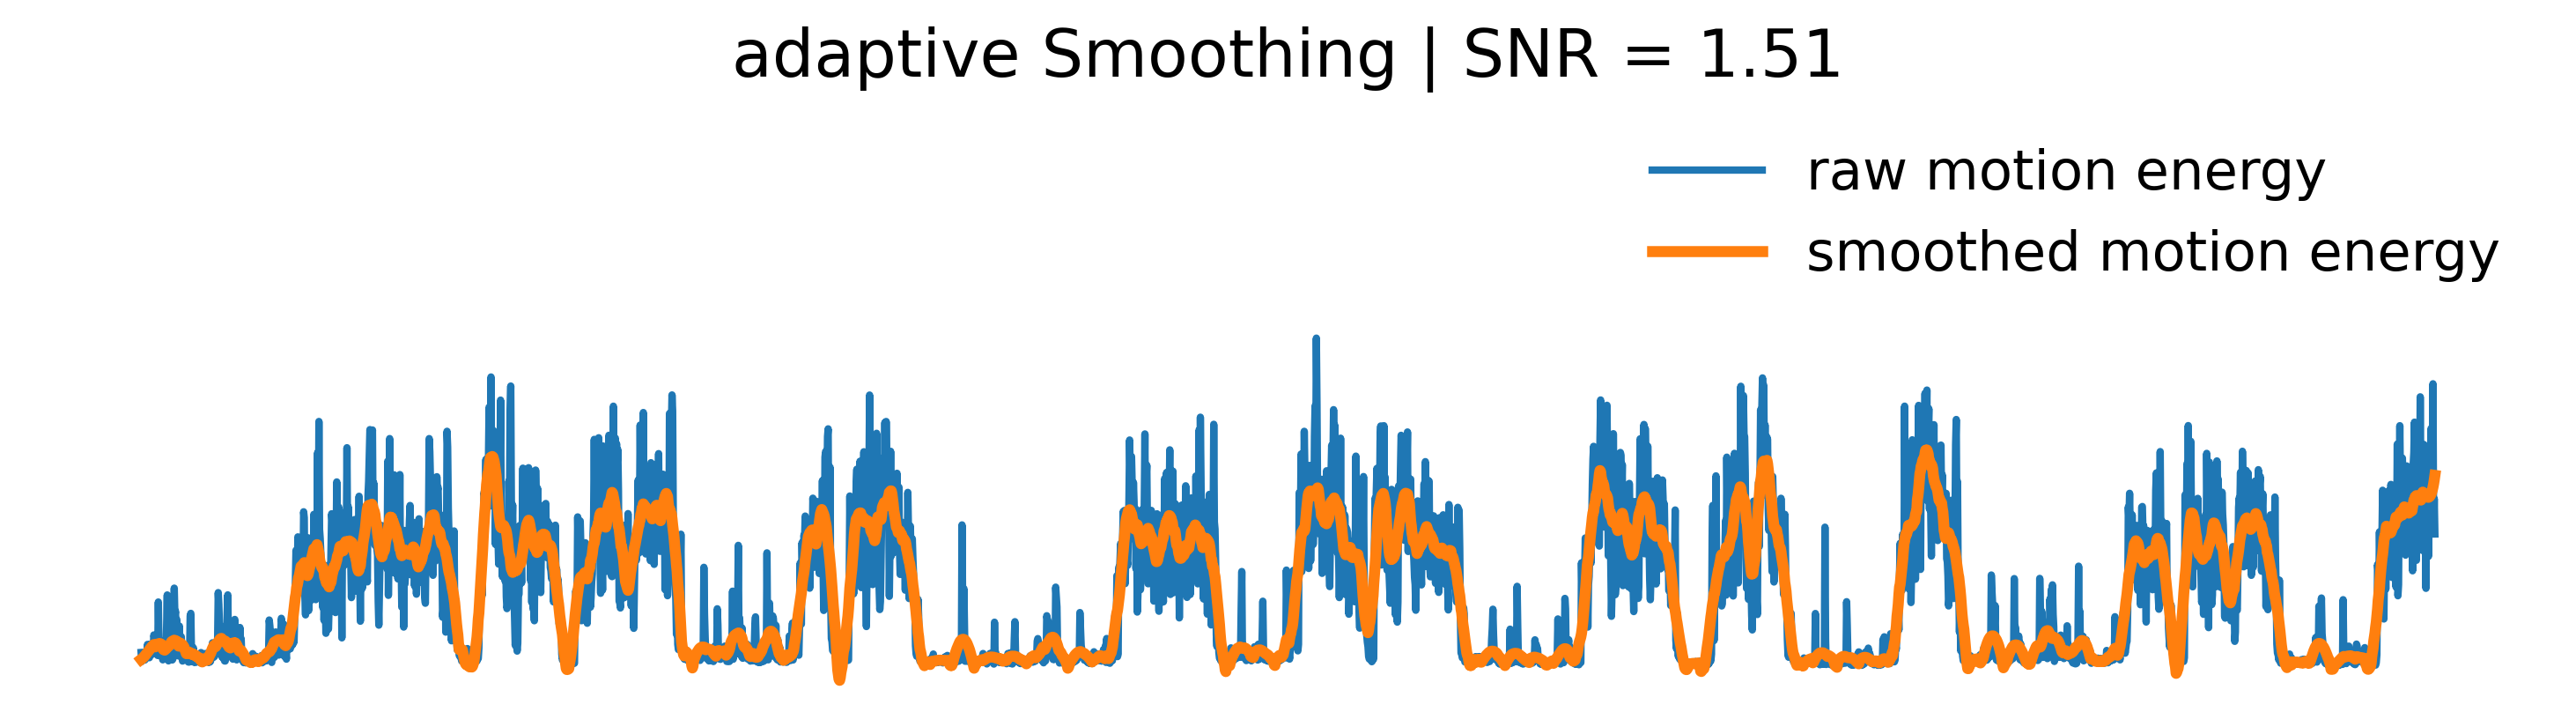

In [15]:
min_window_secs = 1* target_fps  # minimal smoothing in seconds
max_window_secs = 5 *target_fps  # maximal smoothing in seconds here 

snr = signaltonoise(motion_energy)
# Map SNR to window size: higher SNR -> shorter window
snr = np.clip(snr, 0.1, 10)  # avoid divide-by-zero or extremes
snr_norm = (10 - snr) / 9.9  # normalize to [0, 1]
adaptive_window_secs = min_window_secs + snr_norm * (max_window_secs - min_window_secs)
adaptive_window_length = int(adaptive_window_secs * target_fps)

# Ensure odd and >= polyorder+2
polyorder = 3
if adaptive_window_length % 2 == 0:
    adaptive_window_length += 1
adaptive_window_length = max(adaptive_window_length, polyorder + 3)

print(f"Adaptive window length: {adaptive_window_length}")

# smooth 
smoothed_motion_energy = savgol_filter(motion_energy, window_length=adaptive_window_length,
                                       polyorder=polyorder, mode='interp')
# plot 
plt.figure(figsize=(10, 3), dpi=300)
plt.plot(motion_energy, label='raw motion energy', linewidth=2)
plt.plot(smoothed_motion_energy, label='smoothed motion energy', linewidth=3)
plt.ylim(0,1)
plt.legend(frameon=False, loc='upper right')
plt.title(f"adaptive Smoothing | SNR = {snr:.2f}")
sns.despine()
plt.axis('off')
plt.tight_layout()
plt.show()

### Perform bimodality test

Assess whether there are the two distinct motion states (high motion/arousal - low_motion/rest):

Yes: proceed with the extraction of arousal-rest and idenitfy twitches and other unclassified movements during rest period 
No: Then assume we only have rest/sleep state and identify twitches and unclassified other movements during rest 

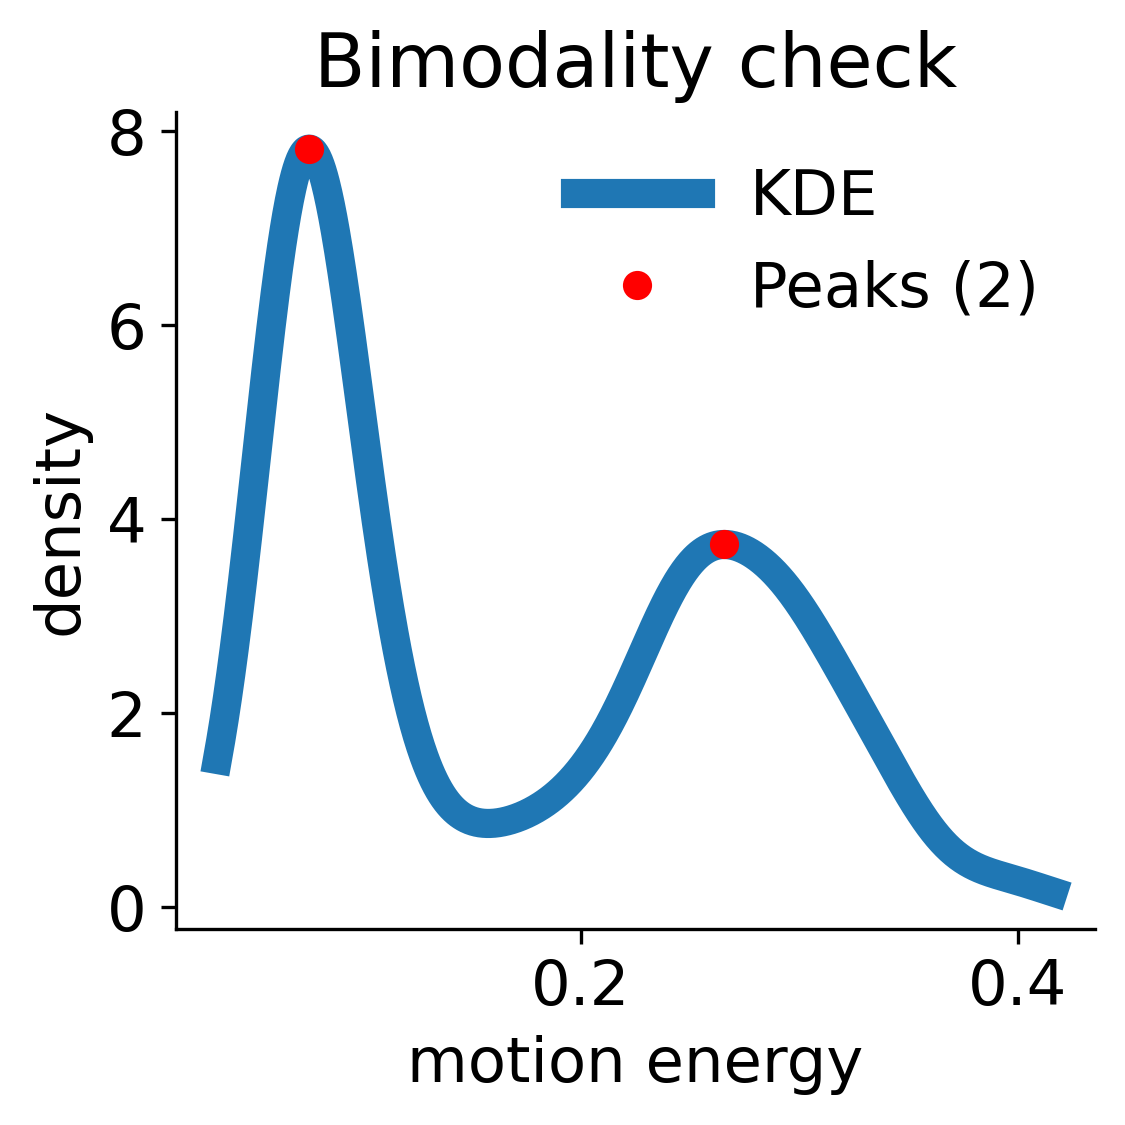

✅ Detected bimodal distribution (2 peaks)


In [16]:
bimodal, bimodality_metrics = bimodality_test(smoothed_motion_energy, kde_prominence=0.1, plot=True)

In [17]:
if bimodality_metrics['dip_p'] < 0.05 or bimodal==True:
    bimodality = True 
else:
    bimodality = False  

### Choose statistical threshold for binarisation

Otsu method is preferred if there is active-wake transition evidently in the motion signal

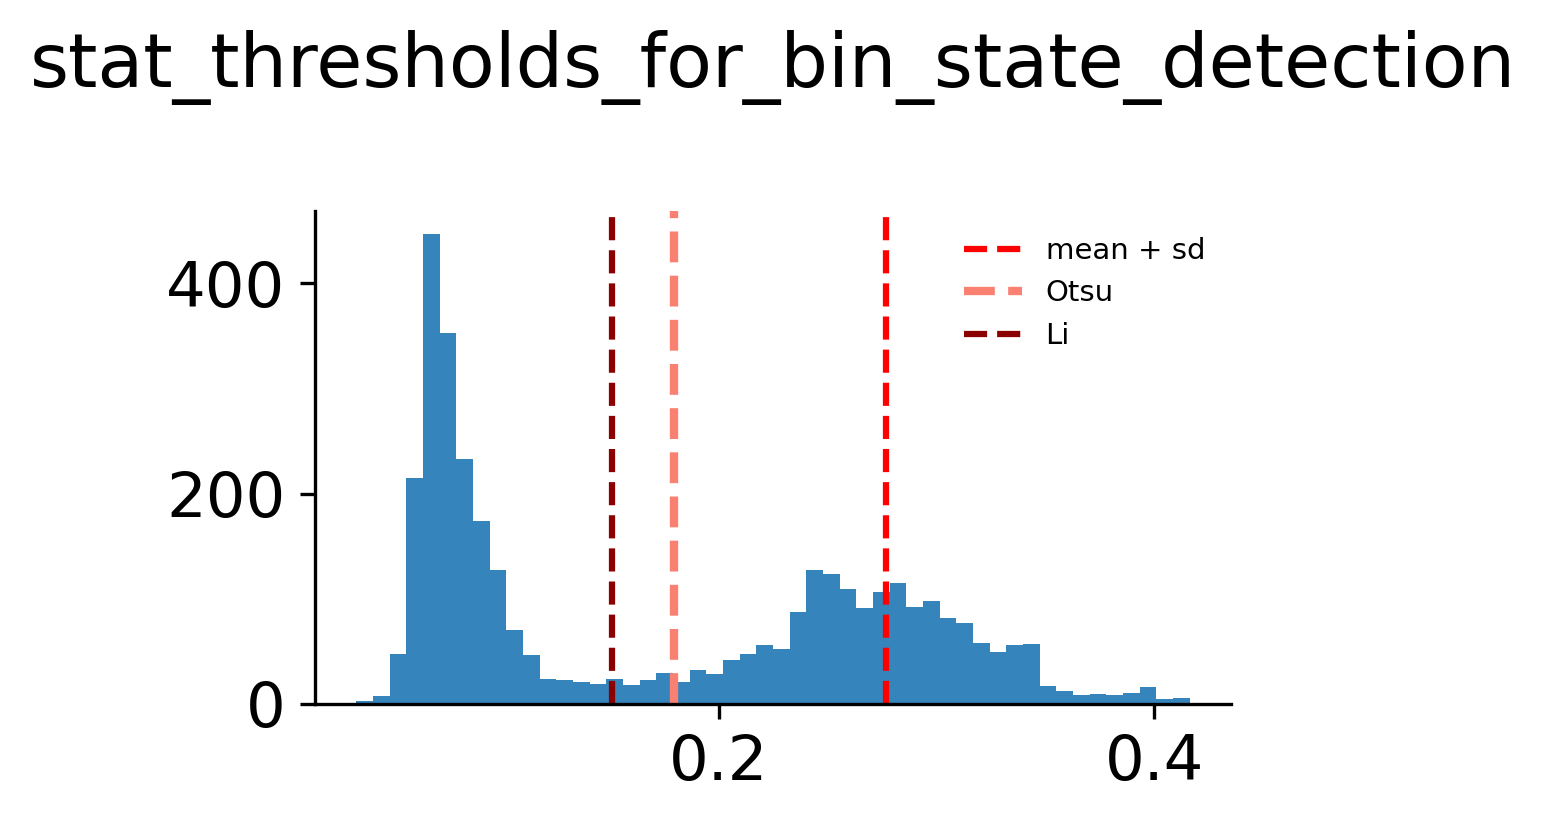

In [18]:
threshold_motion_mean_sd, threshold_motion_li, threshold_motion_otsu = compute_thresholds_for_bin_state_detection(smoothed_motion_energy, title='stat_thresholds_for_bin_state_detection', save_dir=save_dir_videography, plot=True)

### Choose binarisation threshold 

In [19]:
if binary_threshold_method == 'otsu':  # threshold for binary: a/r state detcetion -
    binary_threshold = threshold_motion_otsu
elif binary_threshold_method == 'li':
    binary_threshold = threshold_motion_li
else:
    binary_threshold = threshold_motion_mean_sd 

In [20]:
has_active_motion, bin_motion_energy, inds_active_state, inds_rest_state =  binarise_motion(smoothed_motion_energy, binary_threshold=binary_threshold, min_duration=active_motion_duration_min, min_inactive_gap=9, bimodality=bimodality)

### Plot binarised motion (active/arousal - 1 / Rest - 0)

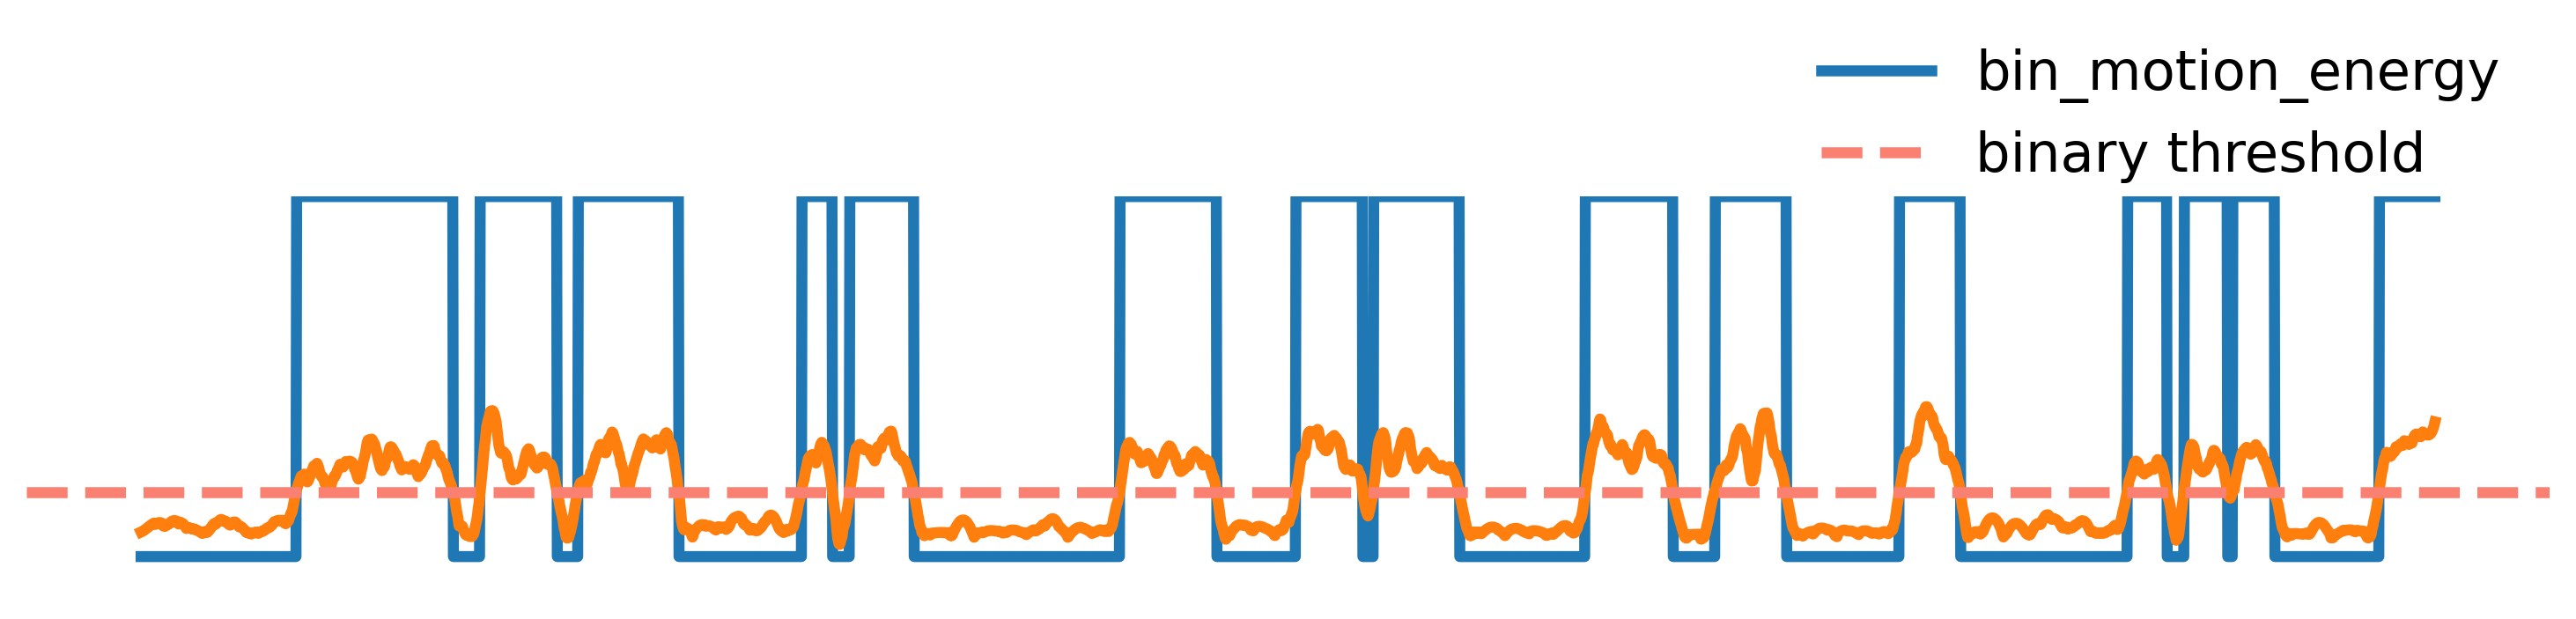

In [21]:
plt.figure(figsize=(10, 3), dpi=300)
plt.plot(bin_motion_energy, linewidth=3, label='bin_motion_energy')
plt.plot(smoothed_motion_energy, linewidth=3)
# plt.title('binary motion_energy', y=1.2)
plt.axhline(y=binary_threshold, color='salmon', linestyle='--', label='binary threshold', linewidth=3)
plt.axis('off')
plt.ylim(-0.1,1)
plt.legend(loc='upper right', frameon=False, bbox_to_anchor=(1,1.5))
sns.despine()
plt.show()

### Define onsets and offsets of active motion 

In [22]:
active_motion_onsets = get_onsets(bin_motion_energy)
active_motion_offsets = get_offsets(bin_motion_energy)

### Classify Active (arousal-related) motions to short / long 

Saved plot to: \Users\zaggila\Documents\deve_2p\data_proc\cells_dual_img\test_mouse_id\mousecraft_automatic_classifications\subplots_bin_motion_energy_classified.png


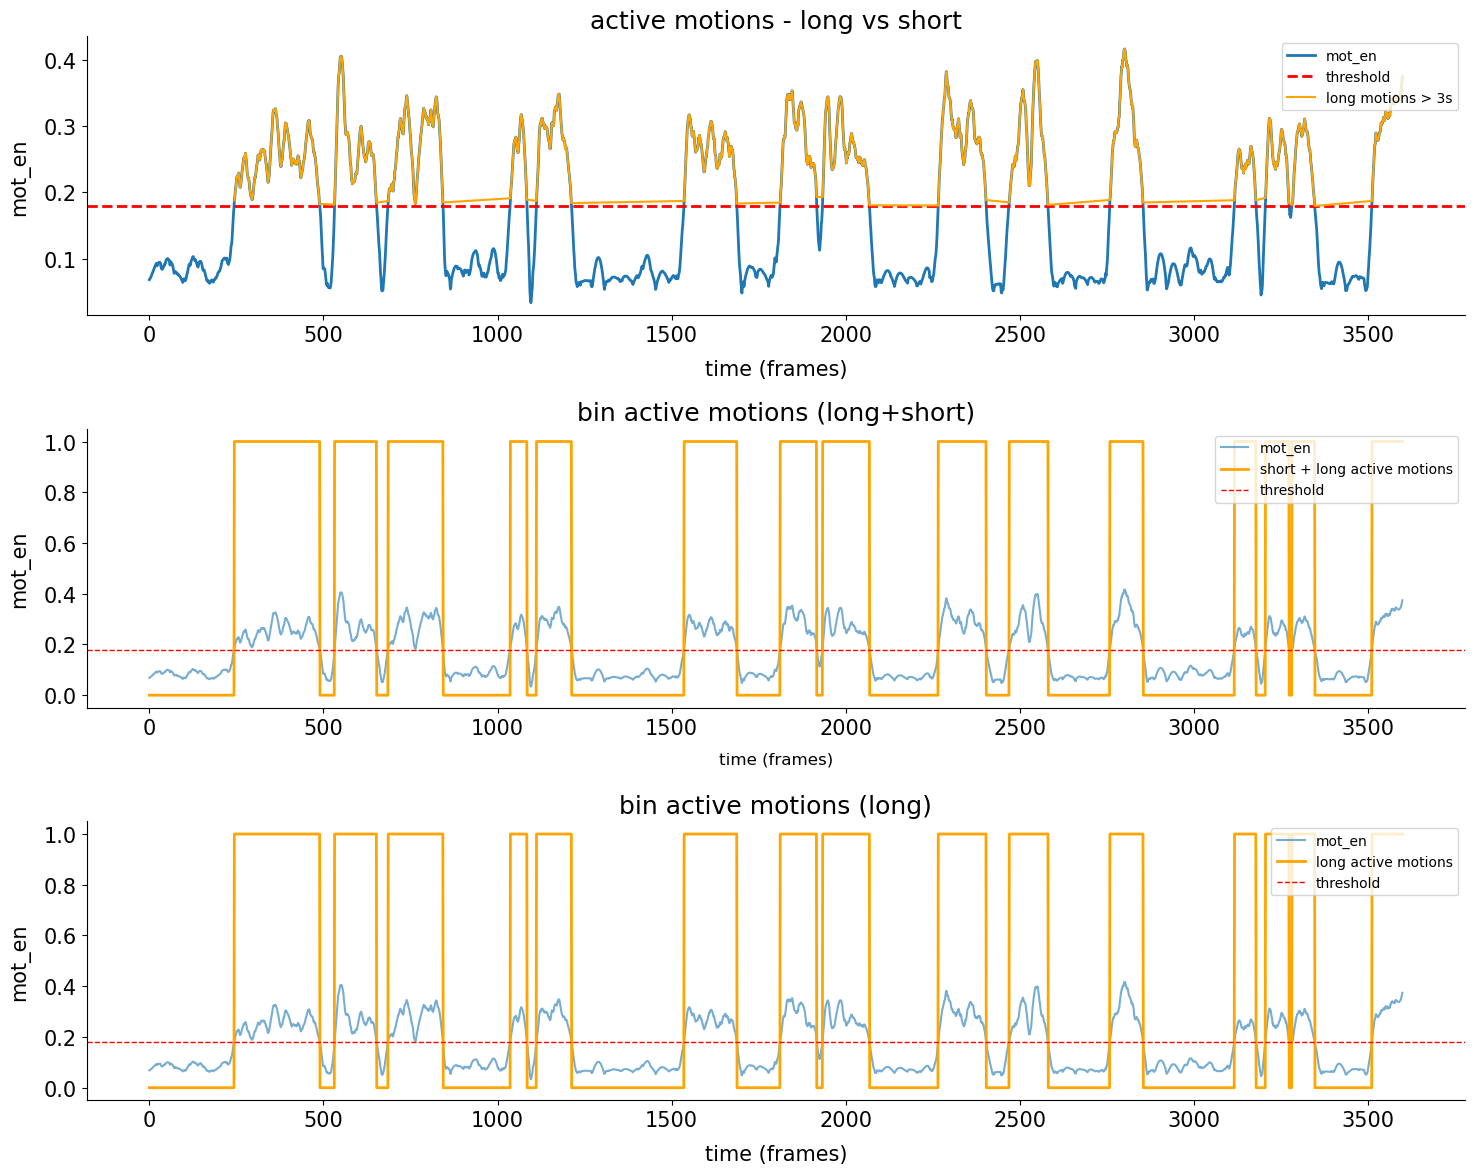

In [23]:
# classify active motions detected 
bin_short_active_motion, short_active_motion_inds, bin_long_active_motion, long_active_motion_inds, bin_too_short_active_motion, too_short_active_motion_inds = classify_active_motion_segments(
    bin_motion_energy,
    motion_energy,
    short_threshold=active_motion_duration_min,
    long_threshold=long_active_motion_duration_min
)

# plot classified active motions detected 
plot_active_motion_classification_subplots(
    motion_signal=motion_energy,
    smoothed_motion_signal=smoothed_motion_energy,
    bin_motion_energy=bin_motion_energy,
    bin_long_active_motion=bin_long_active_motion,
    bin_short_active_motion=bin_short_active_motion,
    long_active_motion_inds=long_active_motion_inds,
    short_active_motion_inds=short_active_motion_inds,
    threshold=threshold_motion_otsu,
    save_path=save_dir_videography / 'subplots_bin_motion_energy_classified.png',
)

In [24]:
# turn indices into continuous segments eg 25-100 is active seg 1, 500-805 active seg 2 etc
if bimodality:
    active_segments = get_active_segments(inds_active_state) #all not only long
    long_active_segments = get_active_segments(long_active_motion_inds) #all not only long , already numpy

### Twitch detection 

In [25]:
rest_period = motion_energy[inds_rest_state] #identify periods of low motion energy ==0 (non smoothed (!))
rest_period = rest_period.flatten()

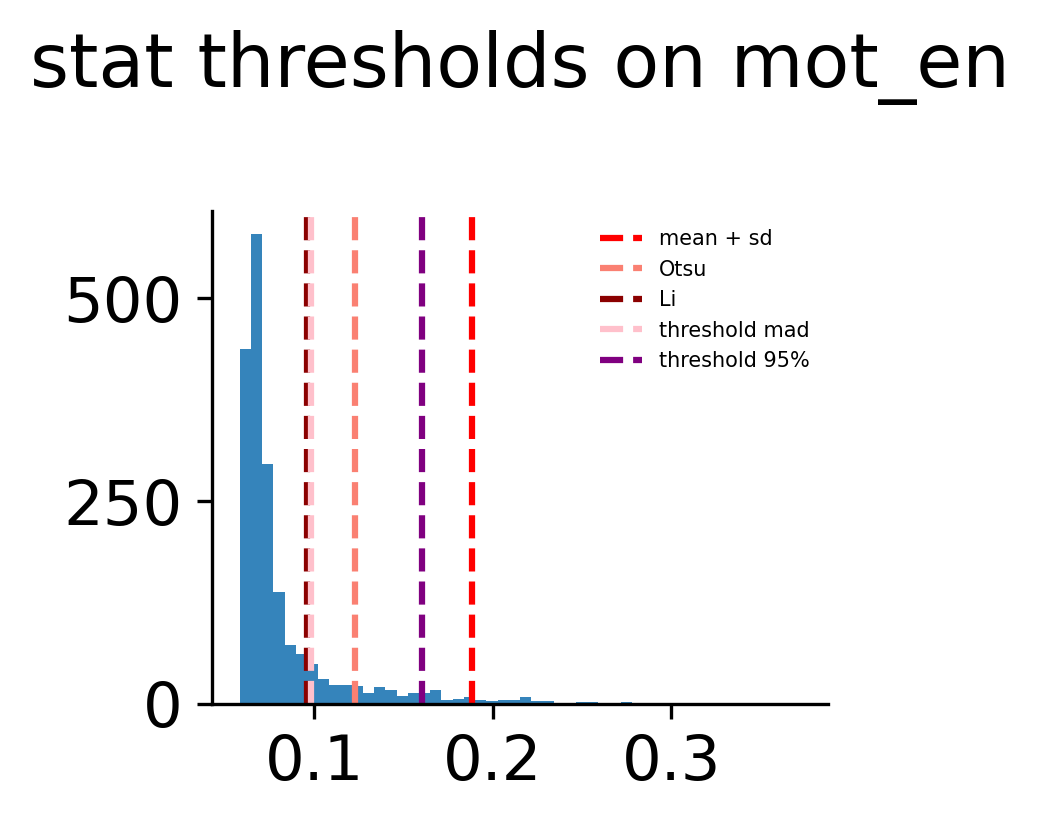

In [26]:
twitch_threshold_motion_mean_sd, twitch_threshold_motion_li, twitch_threshold_motion_otsu, threshold_mad, threshold_95 = compute_thresholds_for_twitch_state_detection(rest_period, save_dir=save_dir_videography, plot=True)

### Choose twitch threshold 

In [27]:
if twitch_threshold_method == 'li':
    twitch_threshold = twitch_threshold_motion_li

elif twitch_threshold_method == 'mad':
    twitch_threshold = twitch_threshold_motion_mad

elif twitch_threshold_method == 'mean_sd':
    twitch_threshold = twitch_threshold_motion_mean_sd

elif twitch_threshold_method == 'otsu':
    twitch_threshold = twitch_threshold_motion_otsu

elif twitch_threshold_method == 'threshold_95':
    twitch_threshold = threshold_95

else:
    raise ValueError(f"Unknown twitch_threshold_method: {twitch_threshold_method}")

In [28]:
inds_twitches_unfiltered = np.where(rest_period > twitch_threshold) #inds of prospective twitches (in array of low motion energy) careful its on the size of low motion array
inds_twitches_unfiltered = inds_rest_state[inds_twitches_unfiltered]
# identify event segments 
unfiltered_putative_twitches_segments = find_sequential_groups(inds_twitches_unfiltered)

In [29]:
# turn twitch array into binary 
bin_putative_twitch = binarise_twitch(motion_energy, unfiltered_putative_twitches_segments) #segs 

Flattened Indices: [20, 21, 23, 27, 28, 37, 40, 41, 52, 53, 54, 55, 56, 60, 63, 77, 78, 121, 122, 123, 124, 128, 135, 136, 137, 146, 147, 149, 153, 155, 156, 157, 201, 202, 203, 207, 210, 211, 213, 217, 218, 219, 220, 221, 222, 223, 224, 229, 230, 231, 233, 235, 236, 238, 240, 241, 242, 243, 490, 491, 492, 493, 494, 495, 497, 498, 531, 653, 654, 655, 656, 657, 658, 659, 681, 682, 683, 684, 685, 846, 847, 848, 883, 884, 885, 904, 905, 926, 928, 930, 931, 935, 936, 937, 938, 939, 940, 943, 963, 964, 965, 982, 983, 985, 986, 987, 989, 990, 991, 992, 993, 996, 999, 1017, 1021, 1022, 1025, 1026, 1027, 1029, 1033, 1034, 1035, 1036, 1111, 1213, 1214, 1219, 1220, 1288, 1289, 1290, 1291, 1292, 1339, 1370, 1371, 1406, 1407, 1421, 1422, 1423, 1424, 1426, 1427, 1429, 1435, 1436, 1437, 1473, 1474, 1515, 1525, 1526, 1528, 1530, 1531, 1534, 1535, 1689, 1690, 1726, 1727, 1759, 1760, 1797, 1798, 1806, 1807, 1808, 1809, 1810, 1811, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 2069, 2070, 2075, 2076, 

### Filter twitches 
Filter 1: exclude those too close to awake periods 

Filter 2: Based on expected event duration (eg. for twitches < 1sec)

Filter 3: Remove burst events (subject to change by the user)

In [30]:
# filter 1
inds_twitches_filtered_step1 = filter_twitches_by_awake_proximity(inds_twitches_unfiltered, inds_active_state, min_distance=twitch_min_distance_from_active) 

In [31]:
inds_twitches_segments = find_sequential_groups(inds_twitches_filtered_step1)

if len(inds_active_state) > 1: #becs it has length 1 its an empty list inside the array 
    active_motion_segments = find_sequential_groups(inds_active_state)
else:
    active_motion_segments = []  # or handle empty case appropriately
    
resting_motion_segments = find_sequential_groups(inds_rest_state)

In [32]:
# filter 2  
inds_twitches_filtered_step2 = filter_segments_by_duration(inds_twitches_segments, twitch_duration_max)

In [33]:
bin_twitch_unfilt = binarise_twitch(motion_energy, inds_twitches_filtered_step2)

Flattened Indices: [20, 21, 23, 27, 28, 37, 40, 41, 52, 53, 54, 55, 56, 60, 63, 77, 78, 121, 122, 123, 124, 128, 135, 136, 137, 146, 147, 149, 153, 155, 156, 157, 904, 905, 926, 928, 930, 931, 935, 936, 937, 938, 939, 940, 943, 963, 964, 965, 982, 983, 985, 986, 987, 989, 990, 991, 1288, 1289, 1290, 1291, 1292, 1339, 1370, 1371, 1406, 1407, 1421, 1422, 1423, 1424, 1426, 1427, 1429, 1435, 1436, 1437, 1473, 1474, 1759, 1760, 2119, 2120, 2121, 2122, 2148, 2159, 2160, 2187, 2627, 2642, 2643, 2676, 2677, 2903, 2904, 2905, 2906, 2907, 2908, 2909, 2939, 2940, 2941, 2944, 2945, 2946, 2947, 2979, 2980, 2982, 2983, 2985, 2995, 2996, 2997, 2998, 2999, 3000, 3001, 3012, 3014, 3019, 3020, 3022, 3039, 3040, 3041, 3042, 3044, 3045, 3046, 3047, 3049, 3050, 3052, 3412, 3417, 3418, 3419, 3420, 3421, 3422, 3423, 3455]
Assigning 1 at column 20
Assigning 1 at column 21
Assigning 1 at column 23
Assigning 1 at column 27
Assigning 1 at column 28
Assigning 1 at column 37
Assigning 1 at column 40
Assigning 1 at

### Define onset and offset of twitch events

In [34]:
active_onsets = get_onsets(bin_motion_energy)
active_offsets = get_offsets(bin_motion_energy)
twitch_onsets = get_onsets(bin_twitch_unfilt)
twitch_offsets = get_offsets(bin_twitch_unfilt)

### Plot twitch interval

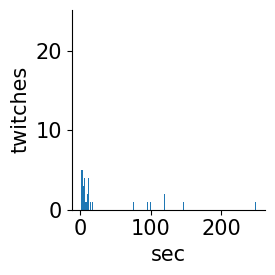

In [35]:
iti = np.diff(twitch_onsets/target_fps)

plt.figure(figsize=(3,3))
plt.hist(iti.flatten(), bins=200)
plt.xlabel('sec')
plt.ylabel('twitches')
plt.show()
# most twithces occur in burst fashion 

### Filter twitches based on inter-twitch-interval
(aka discard bursts, keep sparse 'trusted' twitches)

In [36]:
# filter 3 
inds_twitches_filtered_final = filter_bursty_twitches(inds_twitches_filtered_step2, min_frame_gap=1) # 1 frame is ~330 ms

In [37]:
bin_twitch = binarise_twitch(motion_energy, inds_twitches_filtered_final) #expects class segments

twitch_onsets = get_onsets(bin_twitch)
twitch_offsets = get_offsets(bin_twitch)

Flattened Indices: [20, 21, 23, 27, 28, 37, 40, 41, 52, 53, 54, 55, 56, 60, 63, 77, 78, 121, 122, 123, 124, 128, 135, 136, 137, 146, 147, 149, 153, 155, 156, 157, 904, 905, 926, 928, 930, 931, 935, 936, 937, 938, 939, 940, 943, 963, 964, 965, 982, 983, 985, 986, 987, 989, 990, 991, 1288, 1289, 1290, 1291, 1292, 1339, 1370, 1371, 1406, 1407, 1421, 1422, 1423, 1424, 1426, 1427, 1429, 1435, 1436, 1437, 1473, 1474, 1759, 1760, 2119, 2120, 2121, 2122, 2148, 2159, 2160, 2187, 2627, 2642, 2643, 2676, 2677, 2903, 2904, 2905, 2906, 2907, 2908, 2909, 2939, 2940, 2941, 2944, 2945, 2946, 2947, 2979, 2980, 2982, 2983, 2985, 2995, 2996, 2997, 2998, 2999, 3000, 3001, 3012, 3014, 3019, 3020, 3022, 3039, 3040, 3041, 3042, 3044, 3045, 3046, 3047, 3049, 3050, 3052, 3412, 3417, 3418, 3419, 3420, 3421, 3422, 3423, 3455]
Assigning 1 at column 20
Assigning 1 at column 21
Assigning 1 at column 23
Assigning 1 at column 27
Assigning 1 at column 28
Assigning 1 at column 37
Assigning 1 at column 40
Assigning 1 at

<!-- ### Plot twitches detected before and after filtering  -->

### Plot 

In [38]:
save_dir_videography

WindowsPath('/Users/zaggila/Documents/deve_2p/data_proc/cells_dual_img/test_mouse_id/mousecraft_automatic_classifications')

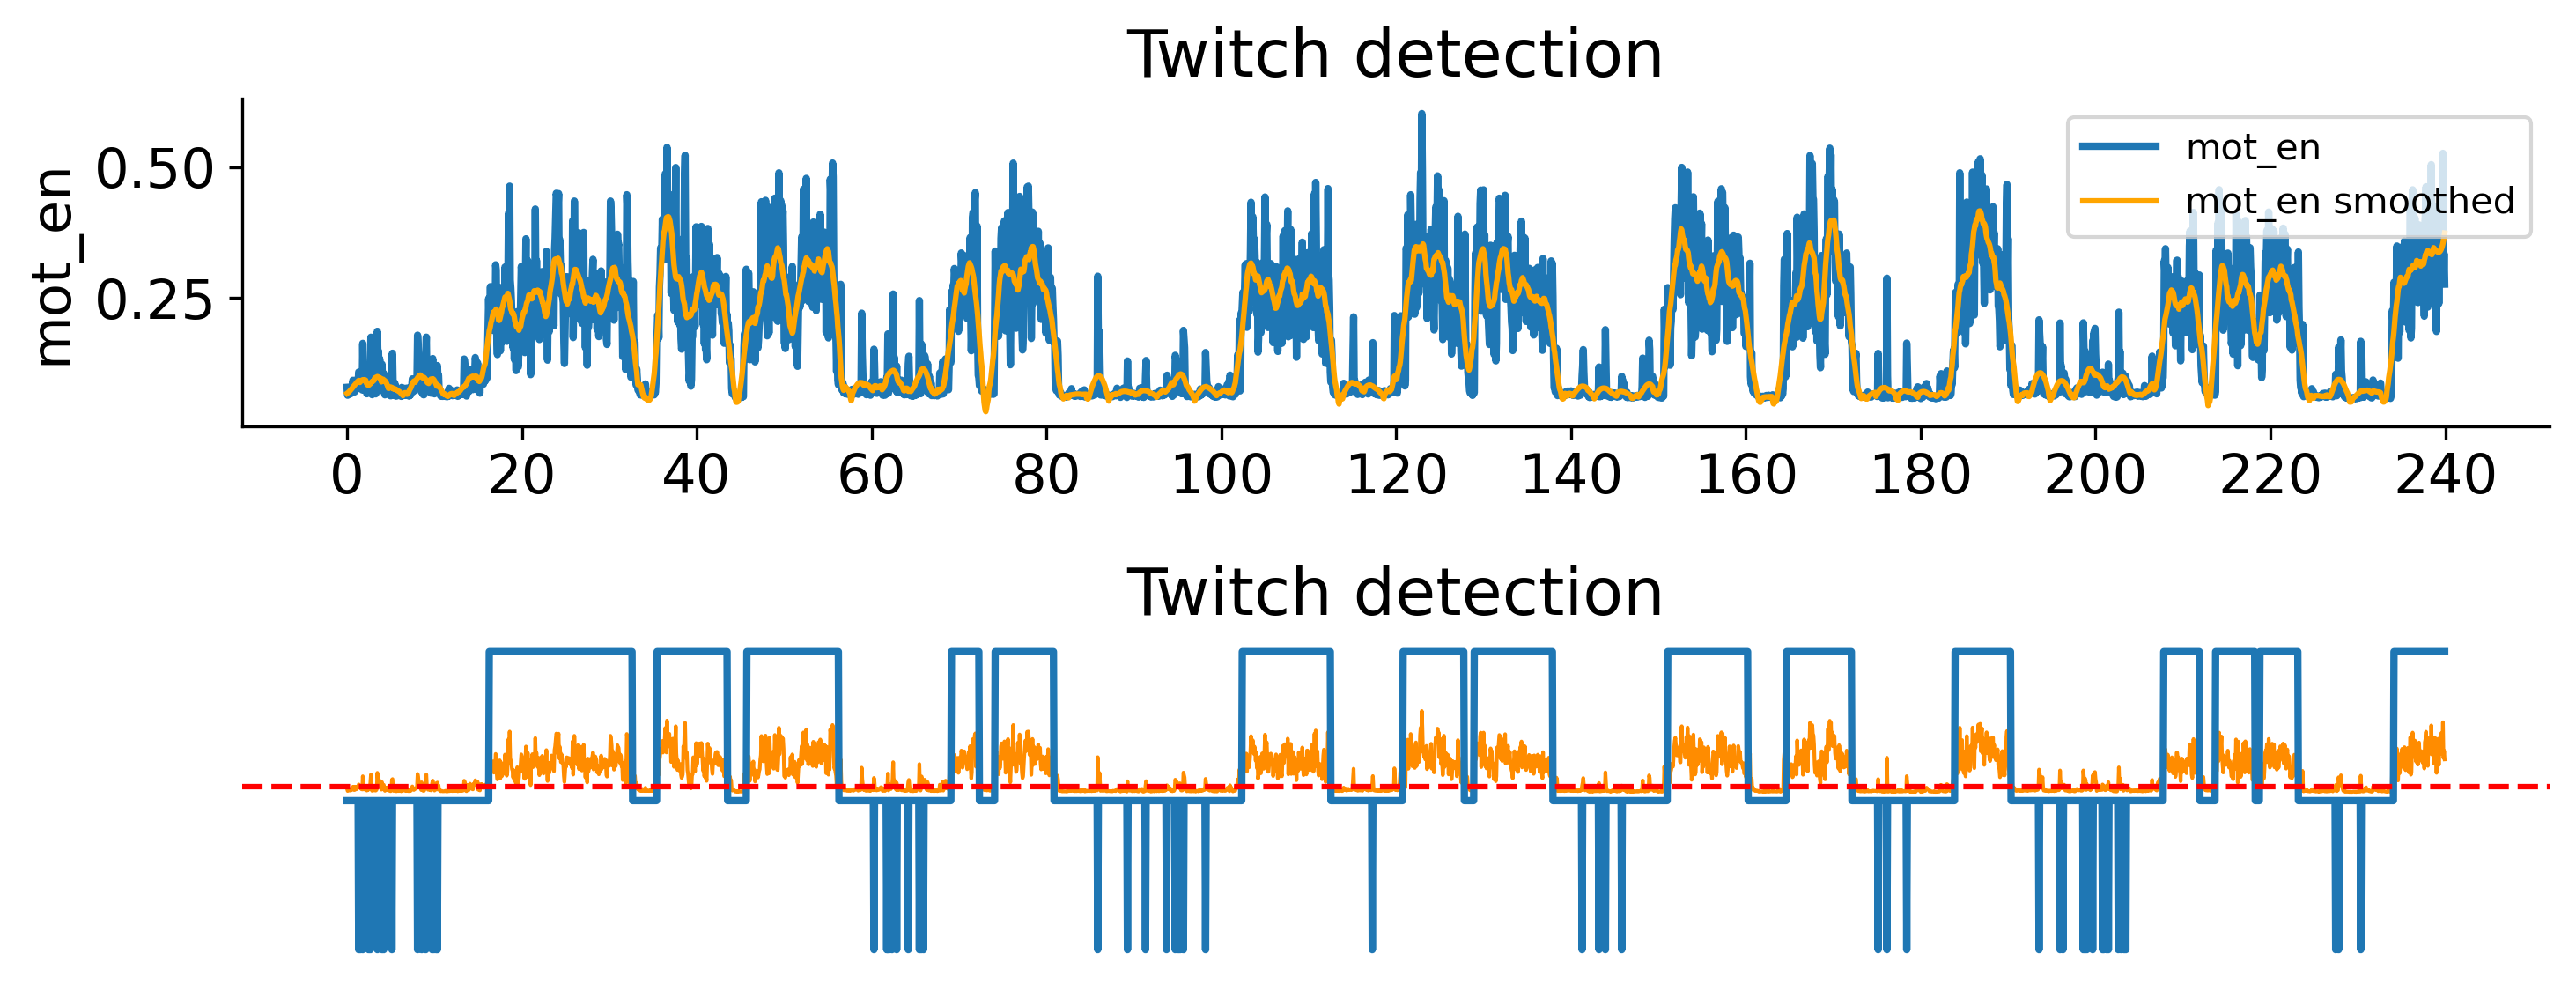

In [39]:
plot_detected_twitches(
    motion_energy=motion_energy,
    smoothed_motion_energy=smoothed_motion_energy,
    bin_motion_energy=bin_motion_energy,
    threshold_twitches=twitch_threshold,
    threshold_motion_energy= binary_threshold,
    inds_twitches=twitch_onsets,
    frame_ticks=frame_ticks,
    second_ticks=second_ticks,
    save_dir=None)

In [40]:
n_twitches = len(twitch_onsets) 
n_active_motions = len(active_motion_segments)

In [41]:
# ========== SUMMARY ==========
print(f"Total active/awake motions detected: {n_active_motions}")
print(f"Total twitches detected: {n_twitches}")

Total active/awake motions detected: 15
Total twitches detected: 61


### Final annotated motion 

In [42]:
classified_behavior, active_and_complex_motions, only_active_motions, complex_motion_segments, complex_onsets, complex_offsets  = get_behavior_classification(bin_putative_twitch, bin_twitch, bin_motion_energy, active_onsets, twitch_onsets)

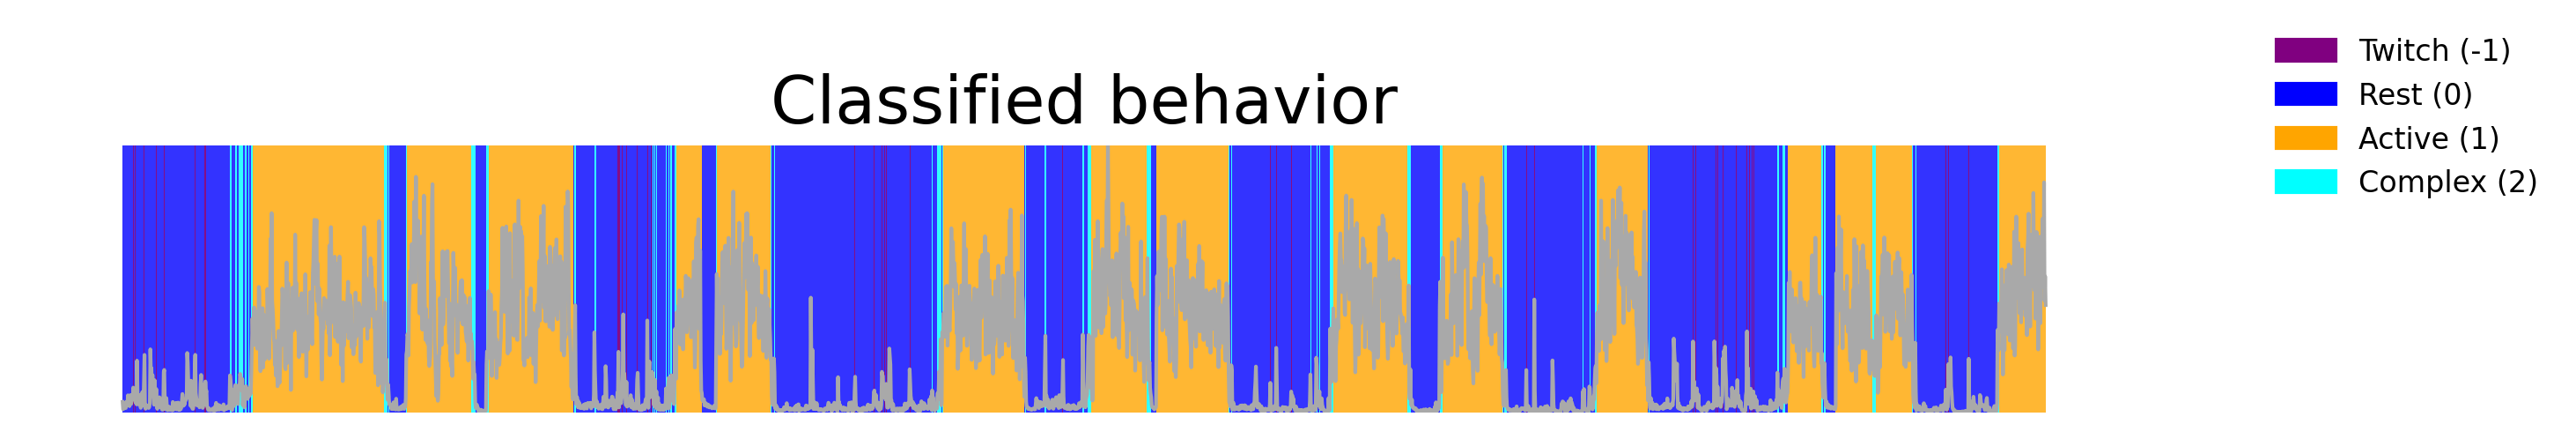

In [44]:
plot_classified_behavior_timeline(classified_behavior, motion_energy, framerate=fps, save_dir=save_dir_videography)

# Save all outputs 

In [45]:
classified_behavior, active_and_complex_motions, only_active_motions, complex_motion_segments, complex_onsets, complex_offsets
auto_detection = {
    'frequency' : target_fps,
    # 'binary_threshold' : 'otsu',
    # 'twitch_threshold' : 'li',
    '+- active_motion_min_distance' : twitch_min_distance_from_active/target_fps , #sec
    'motion_energy_downsampled_2x' : motion_energy,
    'binary_motion_energy' : bin_motion_energy,

    'classified_behavior': classified_behavior, # np.array: classified behavior (pre-curation): 0,1,-1,2 aka Rest, Active, Twitch, Complex
    
    'active_motion_onsets' : active_motion_onsets,
    'active_motion_offsets' : active_motion_offsets,
    'active_motion_segments' : active_motion_segments,

    'active_and_complex_motions':active_and_complex_motions,
    'only_active_motions':only_active_motions,

    'complex_onsets': complex_onsets,
    'complex_offsets': complex_offsets,
    'complex_motion_segments' : complex_motion_segments, #just (onset,offset)

    'binary_twich':bin_twitch, #binary array where 1 == twitch 
    'inds_twitches_segments': inds_twitches_segments,
    'n_twitches' : n_twitches, # no. of twitches 
    'twitch_onsets': twitch_onsets,  # onsets 
    'twitch_offsets': twitch_offsets  # offsets     
}

np.save(save_dir_videography / f'auto_detection.npy', auto_detection)
# np.savez(save_dir + f"auto_detection_{ds}.npz", **auto_detection) 

In [46]:
# save automatic_annotations

In [47]:
automatic_annotations = {
    'active_onsets': active_motion_onsets,
    'active_offsets': active_motion_offsets,
    'twitch_onsets': twitch_onsets, 
    'twitch_offsets': twitch_offsets,
    'complex_onsets': complex_onsets, 
    'complex_offsets' : complex_offsets,
    'validated_active_onsets': [],
    'validated_active_offsets': [],
    'validated_twitch_onsets': [], 
    'validated_twitch_offsets': [],
    'validated_complex_onsets': [], 
    'validated_complex_offsets' : []
}

# Save as Excel
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in automatic_annotations.items()]))
df.to_excel(save_dir_videography/'automatic_annotations.xlsx', index=False)

In [48]:
active_onsets

array([ 244,  532,  686, 1037, 1112, 1536, 1812, 1934, 2266, 2470, 2759,
       3117, 3206, 3282, 3512], dtype=int64)

### Match detected frame indices on the avg back to original time 

In [49]:
avg_block

5

In [50]:
rescaled_annotations = {}
for key, value in automatic_annotations.items():
    if len(value) > 0:
        rescaled_annotations[key] = [int(v * avg_block) for v in value] # matches avg frame to original frame idx 
    else:
        rescaled_annotations[key] = []

# Convert to DataFrame
df_rescaled = pd.DataFrame({k: pd.Series(v) for k, v in rescaled_annotations.items()})

# Save to Excel
df_rescaled.to_excel(save_dir_videography / 'automatic_annotations_rescaled.xlsx', index=False)

In [51]:
os.getcwd()

'C:\\Users\\zaggila\\Documents\\deve_2p'

# Generate input for the GUI:

In [52]:
# Prepare motion energy and total frames
n_frames = len(motion_energy_orig)
frame_idx = np.arange(n_frames)

# Initialize binary arrays (0 = not in state, 1 = in state)
active = np.zeros(n_frames, dtype=int)
twitch = np.zeros(n_frames, dtype=int)
complex_ = np.zeros(n_frames, dtype=int)

# Function to fill ranges between onset and offset
def fill_intervals(onsets, offsets, target_array):
    for on, off in zip(onsets, offsets):
        if 0 <= on < off <= n_frames:
            target_array[on:off] = 1
        elif 0 <= on < n_frames:
            target_array[on:] = 1  # In case offset is missing or out of bounds

# Fill activity intervals
fill_intervals(rescaled_annotations.get("active_onsets", []), rescaled_annotations.get("active_offsets", []), active)
fill_intervals(rescaled_annotations.get("twitch_onsets", []), rescaled_annotations.get("twitch_offsets", []), twitch)
fill_intervals(rescaled_annotations.get("complex_onsets", []), rescaled_annotations.get("complex_offsets", []), complex_)

# Create final framewise DataFrame
df_framewise = pd.DataFrame({
    "frame_idx": frame_idx,
    "motion_energy": motion_energy_orig,
    "active": active,
    "twitch": twitch,
    "complex": complex_
})

# Save as CSV for GUI loading
df_framewise.to_csv(save_dir_videography / f'mousecraft_auto_labels.csv', index=False)

In [53]:
save_dir

'\\Users\\zaggila\\Documents\\deve_2p\\data_proc\\cells_dual_img\\test_mouse_id'